import libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

load dataset

In [ ]:
df=pd.read_csv("/content/restaurant_sales.csv")

quick review

In [ ]:
print(df.head(5))

         date   sales
0  2025-01-01  281.64
1  2025-01-02  212.74
2  2025-01-03  250.61
3  2025-01-04  253.38
4  2025-01-05  253.00


In [ ]:
print(df.shape)

(365, 9)


In [ ]:
print(df.describe())

            sales
count  365.000000
mean   249.464795
std     40.075500
min    176.270000
25%    218.560000
50%    245.370000
75%    279.870000
max    419.330000


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    365 non-null    object 
 1   sales   365 non-null    float64
dtypes: float64(1), object(1)
memory usage: 5.8+ KB
None


Time-series check

In [ ]:
if df.index.name == 'date':
    df.reset_index(inplace=True)
df['date']=pd.to_datetime(df['date'],format='%Y-%m-%d')

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    365 non-null    datetime64[ns]
 1   sales   365 non-null    float64       
 2   lag_7   358 non-null    float64       
 3   lag_30  335 non-null    float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 11.5 KB
None


In [ ]:
df.isnull().sum().sum()

np.int64(37)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.index

DatetimeIndex(['2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04',
               '2025-01-05', '2025-01-06', '2025-01-07', '2025-01-08',
               '2025-01-09', '2025-01-10',
               ...
               '2025-12-22', '2025-12-23', '2025-12-24', '2025-12-25',
               '2025-12-26', '2025-12-27', '2025-12-28', '2025-12-29',
               '2025-12-30', '2025-12-31'],
              dtype='datetime64[ns]', name='date', length=365, freq=None)

In [ ]:
df.index=df['date']

In [ ]:
df.head(5)

,date,sales,lag_7,lag_30
0,2025-01-01,281.64,NaN,NaN
1,2025-01-02,212.74,NaN,NaN
2,2025-01-03,250.61,NaN,NaN
3,2025-01-04,253.38,NaN,NaN
4,2025-01-05,253.00,NaN,NaN


In [ ]:
del df['date']

In [ ]:
df.head(5)

,sales
date,
2025-01-01,281.64
2025-01-02,212.74
2025-01-03,250.61
2025-01-04,253.38
2025-01-05,253.00


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 365 entries, 2025-01-01 to 2025-12-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   sales   365 non-null    float64
dtypes: float64(1)
memory usage: 5.7 KB
None


plot sales trend

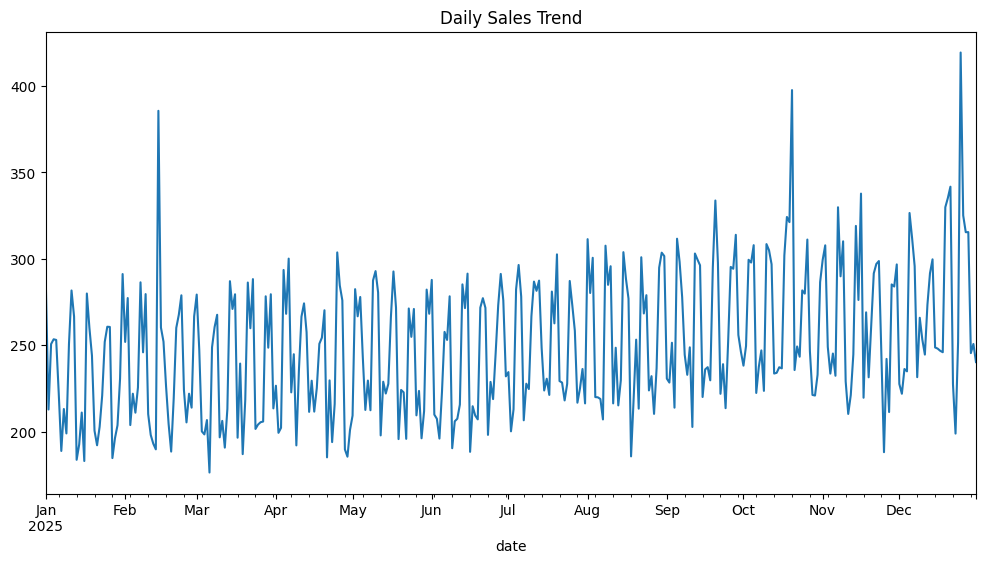

In [ ]:
plt.figure(figsize=(12,6))
df['sales'].plot(title="Daily Sales Trend")
plt.show()

Seasonality check

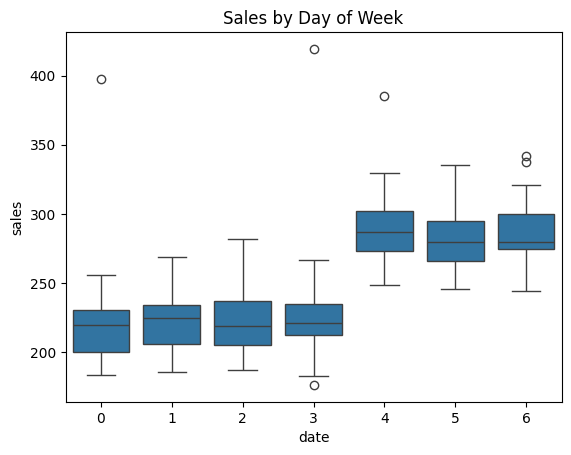

In [ ]:
sns.boxplot(x=df.index.dayofweek, y=df['sales'])
plt.title("Sales by Day of Week")
plt.show()


In [ ]:
from statsmodels.tsa.stattools import adfuller

In [ ]:
result=adfuller(df['sales'])

In [ ]:
print(result[1])

0.805321277897197


In [ ]:
p_value=result[1]

In [ ]:
if p_value < 0.05:
  print("accepted as stationary")
else:
  print("rejected as non stationary")

rejected as non stationary


non-stationary so doing differencing

In [ ]:
rolling_mean=df['sales'].rolling(window=12).mean()

In [ ]:
df_new=df['sales']-rolling_mean

In [ ]:
df_new.head(15)

,sales
date,
2025-01-01,NaN
2025-01-02,NaN
2025-01-03,NaN
2025-01-04,NaN
2025-01-05,NaN
2025-01-06,NaN
2025-01-07,NaN
2025-01-08,NaN
2025-01-09,NaN


on 12th moving avg starts

<Axes: title={'center': 'differenced data'}, xlabel='date'>

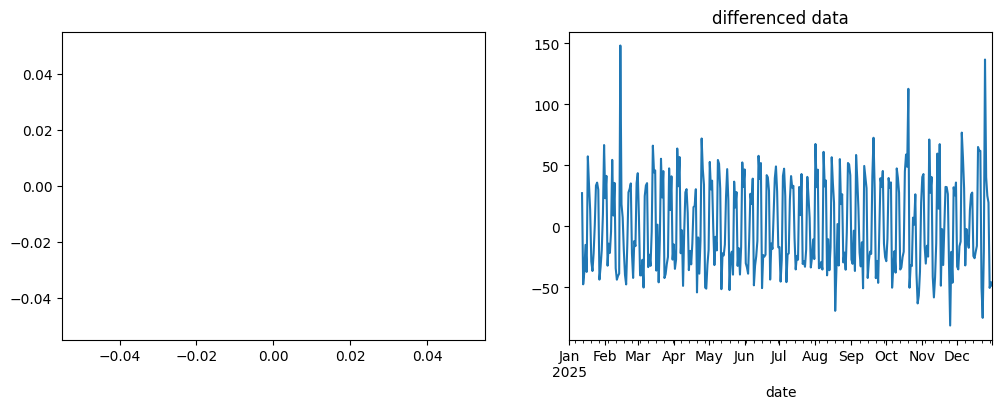

In [ ]:
ax1=plt.subplot(1,2,1)
ax1.plot(figsize=(12,4),color='tab:red',title ='original data',ax=ax1)
ax2=plt.subplot(1,2,2)
df_new.plot(figsize=(12,4),color='tab:blue',title='differenced data',ax=ax2)

In [ ]:
m=df_new.rolling(window=12).mean()
s=df_new.rolling(window=12).std()

In [ ]:
print(m)

date
2025-01-01          NaN
2025-01-02          NaN
2025-01-03          NaN
2025-01-04          NaN
2025-01-05          NaN
                ...    
2025-12-27    15.093056
2025-12-28    18.892708
2025-12-29    16.417778
2025-12-30    13.961042
2025-12-31     4.495417
Name: sales, Length: 365, dtype: float64


In [ ]:
print(s)

date
2025-01-01          NaN
2025-01-02          NaN
2025-01-03          NaN
2025-01-04          NaN
2025-01-05          NaN
                ...    
2025-12-27    60.282205
2025-12-28    58.861888
2025-12-29    61.259940
2025-12-30    63.244093
2025-12-31    63.422271
Name: sales, Length: 365, dtype: float64


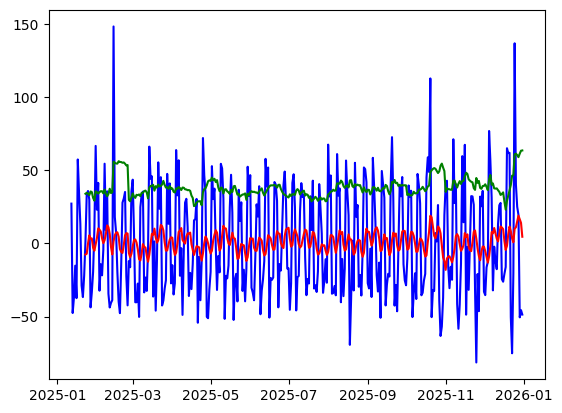

In [ ]:
plt.plot(df_new,color='blue')
plt.plot(m,color='red')
plt.plot(s,color='green')
plt.show()

In [ ]:
df_new.dropna(inplace=True)

In [ ]:
print(df_new.head(15))

date
2025-01-12    27.114167
2025-01-13   -47.598333
2025-01-14   -37.032500
2025-01-15   -15.269167
2025-01-16   -37.438333
2025-01-17    57.262500
2025-01-18    34.253333
2025-01-19    13.527500
2025-01-20   -28.865000
2025-01-21   -36.705000
2025-01-22   -22.074167
2025-01-23     1.122500
2025-01-24    33.365000
2025-01-25    35.747500
2025-01-26    29.960000
Name: sales, dtype: float64


In [ ]:
result=adfuller(df_new)
p_value=result[1]
if p_value < 0.05:
  print("accepted as stationary")
else:
  print("rejected as non stationary")

accepted as stationary


Lag features

In [ ]:

df['lag_7'] = df['sales'].shift(7)
df['lag_30'] = df['sales'].shift(30)


In [ ]:
print(df['lag_7'])

date
2025-01-01       NaN
2025-01-02       NaN
2025-01-03       NaN
2025-01-04       NaN
2025-01-05       NaN
               ...  
2025-12-27    335.16
2025-12-28    341.68
2025-12-29    227.39
2025-12-30    198.80
2025-12-31    251.66
Name: lag_7, Length: 365, dtype: float64


In [ ]:
print(df['lag_30'])

date
2025-01-01       NaN
2025-01-02       NaN
2025-01-03       NaN
2025-01-04       NaN
2025-01-05       NaN
               ...  
2025-12-27    211.27
2025-12-28    285.13
2025-12-29    283.91
2025-12-30    296.70
2025-12-31    227.51
Name: lag_30, Length: 365, dtype: float64


 Rolling averages

In [ ]:
df['rolling_7'] = df['sales'].rolling(7).mean()
df['rolling_14'] = df['sales'].rolling(14).mean()

In [ ]:
print(df['rolling_7'])

date
2025-01-01           NaN
2025-01-02           NaN
2025-01-03           NaN
2025-01-04           NaN
2025-01-05           NaN
                 ...    
2025-12-27    297.040000
2025-12-28    293.285714
2025-12-29    295.854286
2025-12-30    303.264286
2025-12-31    301.624286
Name: rolling_7, Length: 365, dtype: float64


In [ ]:
print(df['rolling_14'])

date
2025-01-01           NaN
2025-01-02           NaN
2025-01-03           NaN
2025-01-04           NaN
2025-01-05           NaN
                 ...    
2025-12-27    288.080714
2025-12-28    289.206429
2025-12-29    288.972143
2025-12-30    289.164286
2025-12-31    288.697857
Name: rolling_14, Length: 365, dtype: float64


 Date-based features

In [ ]:
df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

In [ ]:
print(df['day_of_week'])

date
2025-01-01    2
2025-01-02    3
2025-01-03    4
2025-01-04    5
2025-01-05    6
             ..
2025-12-27    5
2025-12-28    6
2025-12-29    0
2025-12-30    1
2025-12-31    2
Name: day_of_week, Length: 365, dtype: int32


In [ ]:
print(df['month'])

date
2025-01-01     1
2025-01-02     1
2025-01-03     1
2025-01-04     1
2025-01-05     1
              ..
2025-12-27    12
2025-12-28    12
2025-12-29    12
2025-12-30    12
2025-12-31    12
Name: month, Length: 365, dtype: int32


In [ ]:
print(df['is_weekend'])

date
2025-01-01    0
2025-01-02    0
2025-01-03    0
2025-01-04    1
2025-01-05    1
             ..
2025-12-27    1
2025-12-28    1
2025-12-29    0
2025-12-30    0
2025-12-31    0
Name: is_weekend, Length: 365, dtype: int64


External signals (temperature, rainfall, local events)

Merge weather data

In [ ]:
weather = pd.read_csv("/content/Daily_Weather_Insights.csv")


In [ ]:
print(weather.head(5))

         Date   City  Temperature_High (°C)  Temperature_Low (°C)  \
0  2025-01-01  Cairo                   16.9                  14.1   
1  2025-01-02  Cairo                   15.1                   5.6   
2  2025-01-03  Cairo                   25.1                  18.2   
3  2025-01-04  Cairo                   28.9                   9.9   
4  2025-01-05  Cairo                   17.6                  13.7   

   Humidity (%)  Wind_Speed (km/h) Weather_Condition  Air_Quality_Index  \
0          43.1               24.2             Sunny                145   
1          56.9                8.2             Windy                115   
2          52.5               18.2             Snowy                 11   
3          76.3               18.8             Rainy                 22   
4          55.6               10.8             Sunny                 39   

   Precipitation (mm)  Visibility (km)  
0                17.2              4.7  
1                 0.5              9.8  
2          

In [ ]:
print(weather.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   90 non-null     object 
 1   City                   90 non-null     object 
 2   Temperature_High (°C)  90 non-null     float64
 3   Temperature_Low (°C)   90 non-null     float64
 4   Humidity (%)           90 non-null     float64
 5   Wind_Speed (km/h)      90 non-null     float64
 6   Weather_Condition      90 non-null     object 
 7   Air_Quality_Index      90 non-null     int64  
 8   Precipitation (mm)     90 non-null     float64
 9   Visibility (km)        90 non-null     float64
dtypes: float64(6), int64(1), object(3)
memory usage: 7.2+ KB
None


In [ ]:
print(weather.describe())

       Temperature_High (°C)  Temperature_Low (°C)  Humidity (%)  \
count              90.000000             90.000000     90.000000   
mean               25.588889             12.632222     52.785556   
std                 5.648614              4.077393     14.935694   
min                15.100000              5.200000     30.300000   
25%                20.625000              9.100000     41.025000   
50%                26.800000             12.500000     49.550000   
75%                29.575000             16.075000     64.475000   
max                34.900000             19.800000     78.100000   

       Wind_Speed (km/h)  Air_Quality_Index  Precipitation (mm)  \
count          90.000000          90.000000           90.000000   
mean           14.178889         105.300000            9.557778   
std             5.677780          56.111736            6.048326   
min             5.100000          11.000000            0.400000   
25%             9.575000          59.000000         

In [ ]:
print(weather.isnull().sum())

City                     0
Temperature_High (°C)    0
Temperature_Low (°C)     0
Humidity (%)             0
Wind_Speed (km/h)        0
Weather_Condition        0
Air_Quality_Index        0
Precipitation (mm)       0
Visibility (km)          0
dtype: int64


In [ ]:
print(weather.duplicated().sum())

0


In [ ]:
print(weather.shape)

(90, 9)


In [ ]:
weather.index = pd.to_datetime(weather.index, format='%Y-%m-%d', errors='coerce')

In [ ]:
print(weather.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 90 entries, 2025-01-01 to 2025-03-31
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   City                   90 non-null     object 
 1   Temperature_High (°C)  90 non-null     float64
 2   Temperature_Low (°C)   90 non-null     float64
 3   Humidity (%)           90 non-null     float64
 4   Wind_Speed (km/h)      90 non-null     float64
 5   Weather_Condition      90 non-null     object 
 6   Air_Quality_Index      90 non-null     int64  
 7   Precipitation (mm)     90 non-null     float64
 8   Visibility (km)        90 non-null     float64
dtypes: float64(6), int64(1), object(2)
memory usage: 7.0+ KB
None


In [ ]:
print(weather.head(5))

             City  Temperature_High (°C)  Temperature_Low (°C)  Humidity (%)  \
Date                                                                           
2025-01-01  Cairo                   16.9                  14.1          43.1   
2025-01-02  Cairo                   15.1                   5.6          56.9   
2025-01-03  Cairo                   25.1                  18.2          52.5   
2025-01-04  Cairo                   28.9                   9.9          76.3   
2025-01-05  Cairo                   17.6                  13.7          55.6   

            Wind_Speed (km/h) Weather_Condition  Air_Quality_Index  \
Date                                                                 
2025-01-01               24.2             Sunny                145   
2025-01-02                8.2             Windy                115   
2025-01-03               18.2             Snowy                 11   
2025-01-04               18.8             Rainy                 22   
2025-01-05         

In [ ]:
df = df.merge(weather, left_index=True, right_index=True, how='left')

In [ ]:
print(df.head(5))

          date   sales  lag_7  lag_30  rolling_7  rolling_14  day_of_week  \
0.0 2025-01-01  281.64    NaN     NaN        NaN         NaN            2   
1.0 2025-01-02  212.74    NaN     NaN        NaN         NaN            3   
2.0 2025-01-03  250.61    NaN     NaN        NaN         NaN            4   
3.0 2025-01-04  253.38    NaN     NaN        NaN         NaN            5   
4.0 2025-01-05  253.00    NaN     NaN        NaN         NaN            6   

     month  is_weekend       Date  ... Visibility (km)_x  City_y  \
0.0      1           0 2025-01-01  ...               4.7     NaN   
1.0      1           0 2025-01-02  ...               9.8     NaN   
2.0      1           0 2025-01-03  ...               2.5     NaN   
3.0      1           1 2025-01-04  ...               9.4     NaN   
4.0      1           1 2025-01-05  ...               4.5     NaN   

     Temperature_High (°C)_y  Temperature_Low (°C)_y  Humidity (%)_y  \
0.0                      NaN                     NaN    

Features

In [ ]:
weather['avg_temp'] = (weather['Temperature_High (°C)'] + weather['Temperature_Low (°C)']) / 2
df['temperature'] = weather['avg_temp']
df['rainfall'] = weather['Precipitation (mm)']

In [ ]:
# Event calendar
events = pd.read_csv("local_events_2025.csv")
events['date'] = pd.to_datetime(events['date'])
df = df.merge(events, on='date', how='left')

# Binary flags
df['is_holiday'] = df['holiday'].notnull().astype(int)
df['is_event_day'] = df['event'].notnull().astype(int)
